## Benchmarking Analysis
Here, we analyze the results of the various HPC techniques I'm exploring, and compare results based on the operation I am computing with my benchmark.

I use Julia here because of personal preference.

In [194]:
using CairoMakie
using CSV
using DataFrames

### Reading Data

In [195]:
df = DataFrame(CSV.File("/Users/aarnavsrivastava/Desktop/_/mini-blas/bench_results.csv", skipto=9))

┌ Warning: thread = 1 warning: parsed expected 1 columns, but didn't reach end of line around data row: 1. Parsing extra columns and widening final columnset
└ @ CSV /Users/aarnavsrivastava/.julia/packages/CSV/LiiJM/src/file.jl:593


Row,2026-05-27T16:47:47-04:00,Column2,Column3,Column4,Column5,Column6,Column7,Column8,Column9,Column10,Column11
,String,String15,String15,String15,String15,String31?,String31?,String7?,String15?,String15?,String15
1,name,iterations,real_time,cpu_time,time_unit,bytes_per_second,items_per_second,label,error_occurred,error_message,FLOPS
2,BENCHMARK_axpy_parallel/16384/2,139709,9379.18,5033.61,ns,missing,missing,missing,missing,missing,6.50984e+09
3,BENCHMARK_axpy_parallel/16384/4,107576,12365.4,6166.02,ns,missing,missing,missing,missing,missing,5.31429e+09
4,BENCHMARK_axpy_parallel/16384/8,43000,31330.8,16529.1,ns,missing,missing,missing,missing,missing,1.98245e+09
5,BENCHMARK_axpy_parallel/16384/16,29256,46818.8,23836.8,ns,missing,missing,missing,missing,missing,1.37468e+09
6,BENCHMARK_axpy_parallel/32768/2,95846,11794.1,7357.66,ns,missing,missing,missing,missing,missing,8.90718e+09
7,BENCHMARK_axpy_parallel/32768/4,90148,14102.8,8021.89,ns,missing,missing,missing,missing,missing,8.16965e+09
8,BENCHMARK_axpy_parallel/32768/8,38528,34038.8,17932.3,ns,missing,missing,missing,missing,missing,3.65463e+09
9,BENCHMARK_axpy_parallel/32768/16,29546,46814,23611.8,ns,missing,missing,missing,missing,missing,2.77557e+09


In [196]:
names = df[2:end, 1]
real_times = parse.(Float32, df[2:end, 3])
cpu_times = parse.(Float32, df[2:end, 4])
FLOPS = parse.(Float32, df[2:end, 11])
GFLOPS = FLOPS ./ 1e9

235-element Vector{Float64}:
  6.509839872
  5.314290176
  1.982450048
  1.374680064
  8.907180032
  8.169650176
  3.654629888
  2.77556992
 11.546399744
 11.917800448
  ⋮
 15.54220032
 10.36029952
 10.356599808
  9.992790016
  3.166680064
  2.554380032
  1.958690048
  1.676899968
  1.624509952

In [197]:
baseline_names_indices = findall(name -> contains(name, "baseline"), names)
baseline_names = names[baseline_names_indices]
baseline_real_times = real_times[baseline_names_indices]
baseline_cpu_times = cpu_times[baseline_names_indices]
baseline_FLOPS = FLOPS[baseline_names_indices]
baseline_GFLOPS = GFLOPS[baseline_names_indices]

43-element Vector{Float64}:
  8.92352
  8.850180096
  8.857339904
  8.813339648
  8.709699584
  8.503520256
  8.529690112
 20.1899008
 13.828200448
 13.810400256
  ⋮
 15.54220032
 10.36029952
 10.356599808
  9.992790016
  3.166680064
  2.554380032
  1.958690048
  1.676899968
  1.624509952

In [198]:
baseline_num_elems = []
for name in baseline_names
	ar = split(name, '/')
	push!(baseline_num_elems, parse(Int, ar[2]))
end

baseline_num_elems

43-element Vector{Any}:
   16384
   32768
   65536
  131072
  262144
  524288
 1048576
   16384
   32768
   65536
       ⋮
     128
     256
     512
    1024
      64
     128
     256
     512
    1024

In [199]:
parallel_names_indices = findall(name -> contains(name, "parallel"), names)
parallel_names = names[parallel_names_indices]
parallel_real_times = real_times[parallel_names_indices]
parallel_cpu_times = cpu_times[parallel_names_indices]
parallel_FLOPS = FLOPS[parallel_names_indices]
parallel_GFLOPS = GFLOPS[parallel_names_indices]

152-element Vector{Float64}:
  6.509839872
  5.314290176
  1.982450048
  1.374680064
  8.907180032
  8.169650176
  3.654629888
  2.77556992
 11.546399744
 11.917800448
  ⋮
 23.559299072
  3.383130112
  6.638839808
 12.20499968
 17.994000384
  3.268339968
  6.508610048
 12.16470016
 18.240600064

In [200]:
parallel_num_elems = []
parallel_num_threads = []
for name in parallel_names
	ar = split(name, '/')
	push!(parallel_num_elems, parse(Int, ar[2]))
	push!(parallel_num_threads, parse(Int, ar[3]))
end

In [201]:
nthreads_tested = [2, 4, 8, 16]

threads_2_indices = findall(nthreads -> nthreads == 2, parallel_num_threads)
threads_4_indices = findall(nthreads -> nthreads == 4, parallel_num_threads)
threads_8_indices = findall(nthreads -> nthreads == 8, parallel_num_threads)
threads_16_indices = findall(nthreads -> nthreads == 16, parallel_num_threads)

threads_arr = [threads_2_indices, threads_4_indices, threads_8_indices, threads_16_indices]

4-element Vector{Vector{Int64}}:
 [1, 5, 9, 13, 17, 21, 25, 29, 33, 37  …  113, 117, 121, 125, 129, 133, 137, 141, 145, 149]
 [2, 6, 10, 14, 18, 22, 26, 30, 34, 38  …  114, 118, 122, 126, 130, 134, 138, 142, 146, 150]
 [3, 7, 11, 15, 19, 23, 27, 31, 35, 39  …  115, 119, 123, 127, 131, 135, 139, 143, 147, 151]
 [4, 8, 12, 16, 20, 24, 28, 32, 36, 40  …  116, 120, 124, 128, 132, 136, 140, 144, 148, 152]

In [202]:
function PlotStatistics(names, num_elems, statistics, indices, labels, statistic_name;
    fig = Figure(size=(1200, 1000)),
    baseline_names = nothing,
    baseline_num_elems = nothing,
    baseline_statistics = nothing,
    baseline_label = "baseline"
)
    functions_tested = ["axpy", "scal", "dot", "nrm2", "gemv", "gemm"]
    plots_per_label = nothing

    for (idx, fnt) in enumerate(functions_tested)
        row = mod(idx - 1, 3) + 1
        col = div(idx - 1, 3) + 1
        ax = Axis(fig[row, col];
            title="Number of elements vs $statistic_name for $fnt",
            ylabel=statistic_name,
            xlabel="Number of elements"
        )

        scatters = []

        if !isnothing(baseline_names)
            mask = findall(name -> contains(name, fnt), baseline_names)
            sc = scatter!(ax, baseline_num_elems[mask], baseline_statistics[mask], label=baseline_label, marker=:diamond, color=:black)
            push!(scatters, sc)
        end

        for (i, idxs) in enumerate(indices)
            local_names = names[idxs]
            mask = findall(name -> contains(name, fnt), local_names)
            global_idx = idxs[mask]
            sc = scatter!(ax, num_elems[global_idx], statistics[global_idx], label=labels[i])
            push!(scatters, sc)
        end

        if idx == 1
            plots_per_label = scatters
        end
    end

    all_labels = isnothing(baseline_names) ? labels : [baseline_label; labels]
    Legend(fig[1:3, 3], plots_per_label, all_labels)
    return fig
end

PlotStatistics (generic function with 2 methods)

### Baseline


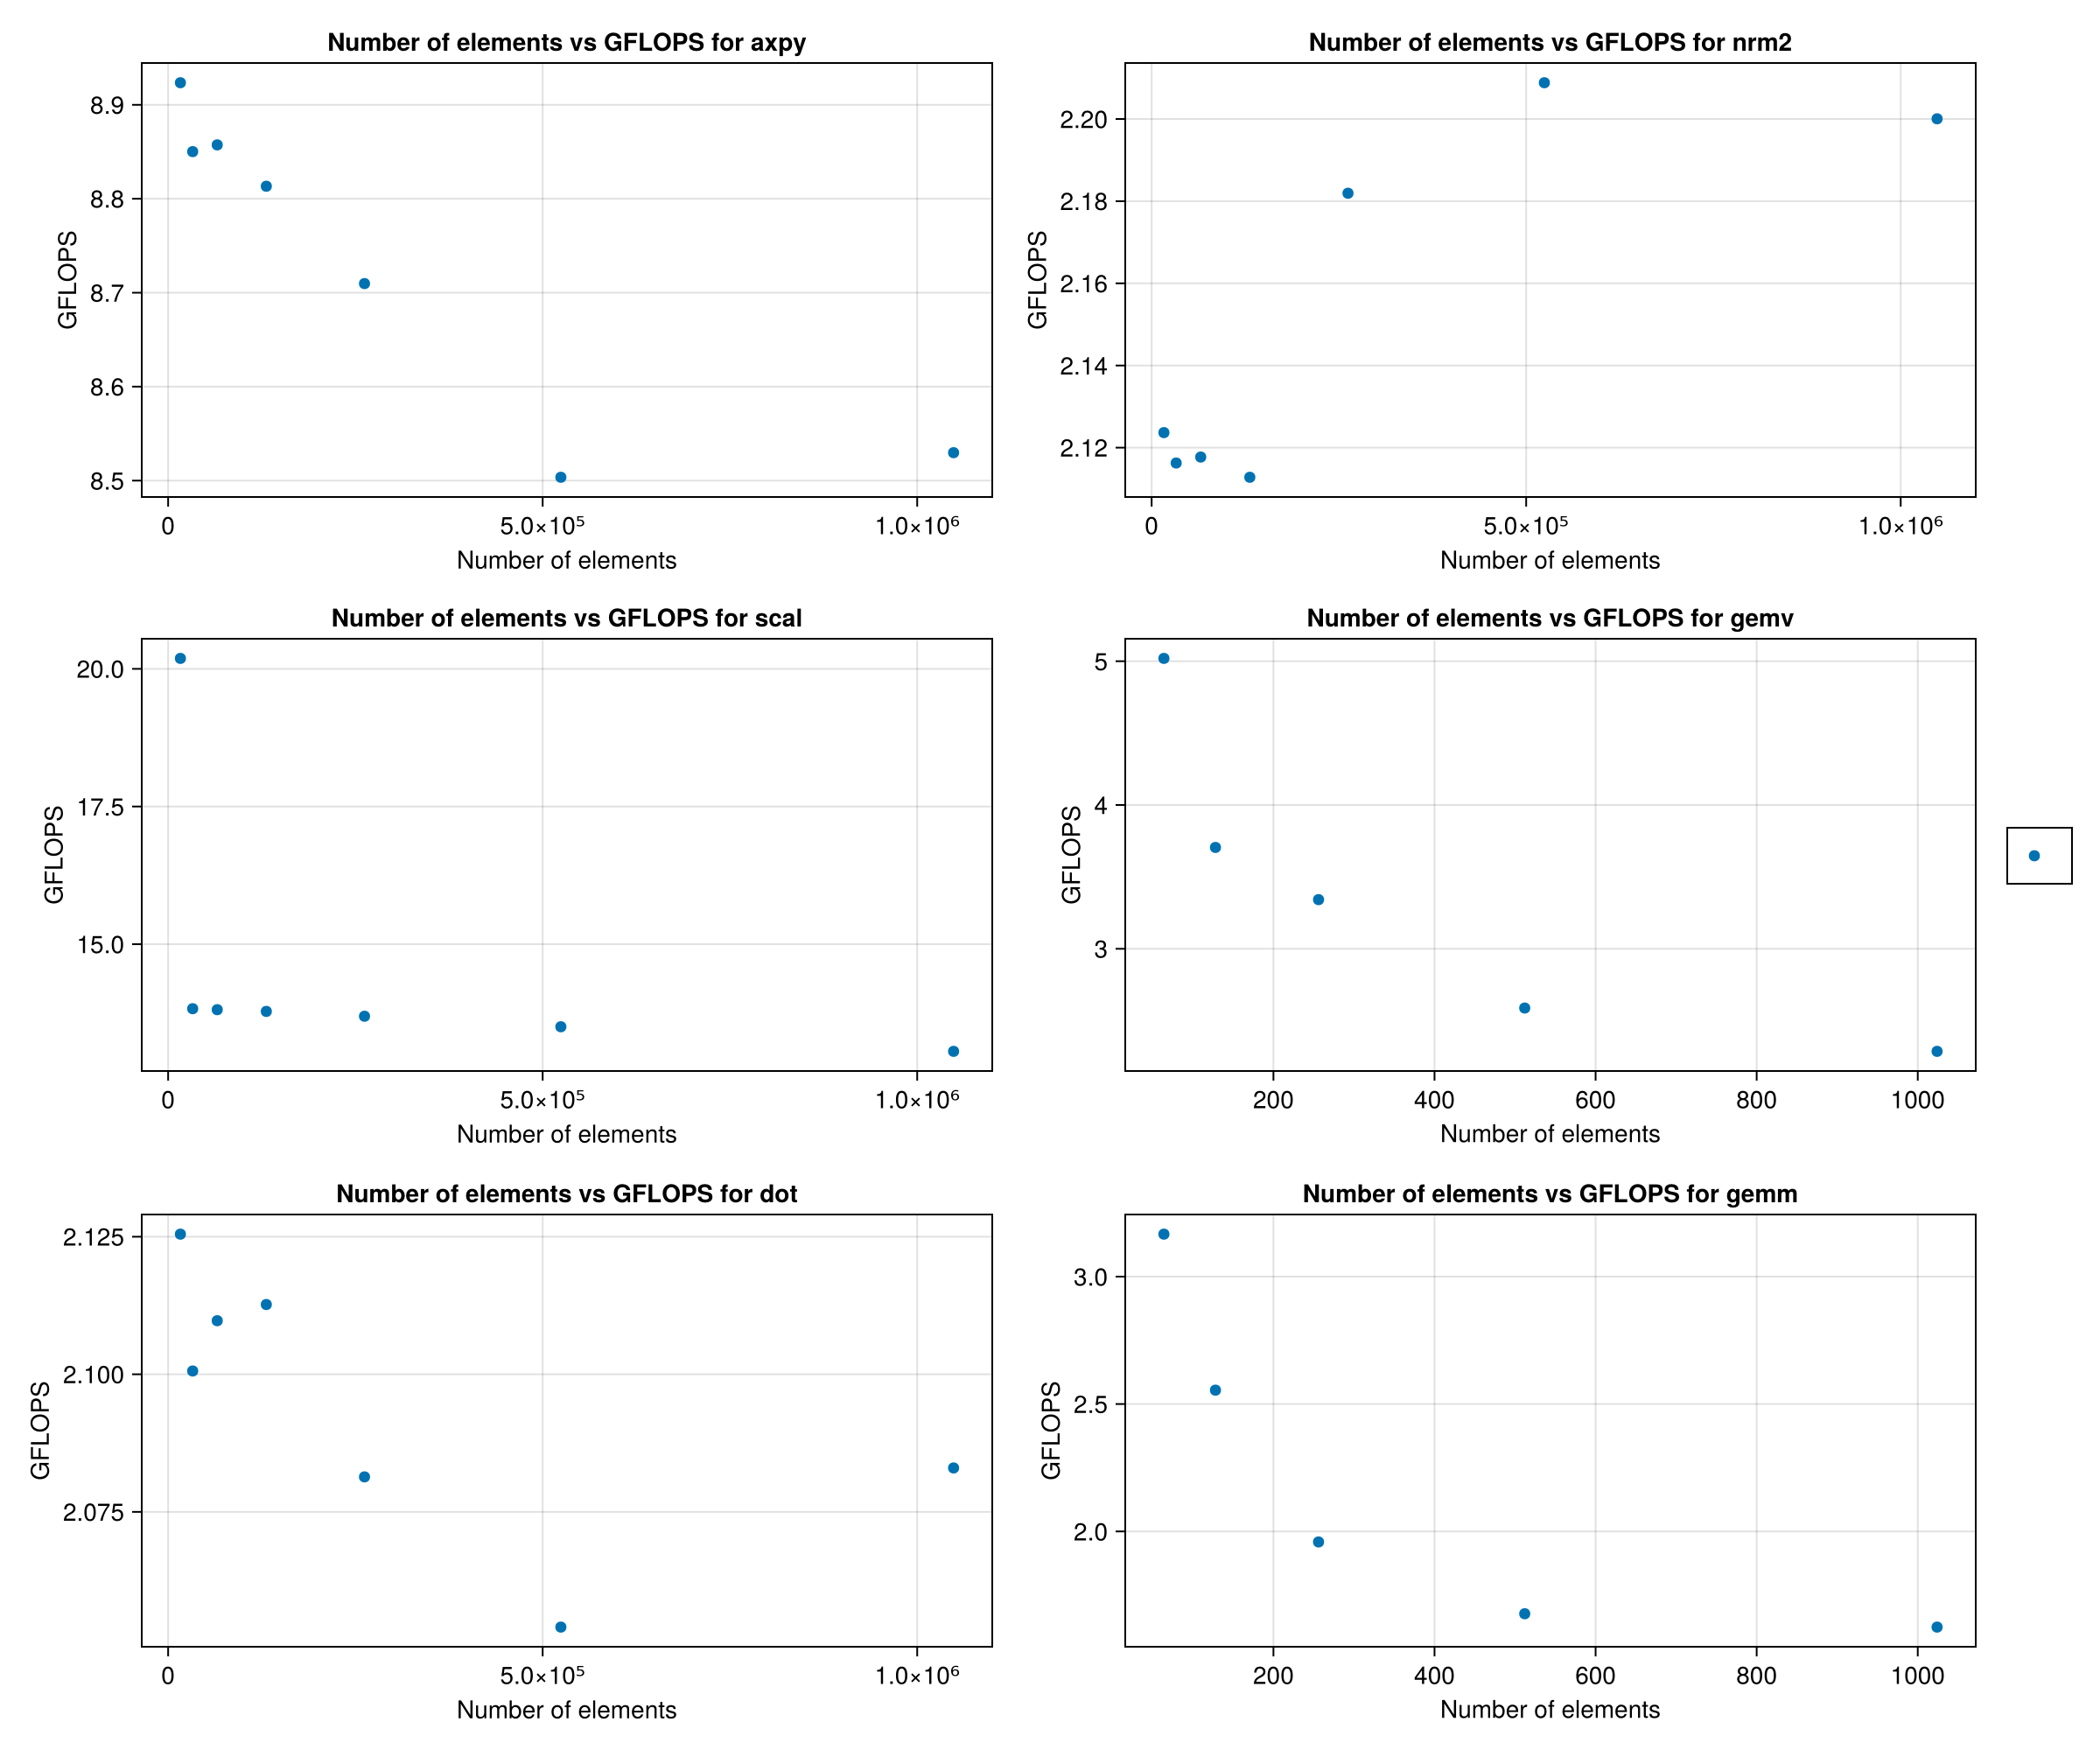

In [203]:
fig = PlotStatistics(baseline_names, baseline_num_elems, baseline_GFLOPS, [range(1, length(baseline_names))], [""], "GFLOPS")
save("./data/baseline_GFLOPS_comparison.png", fig)

fig

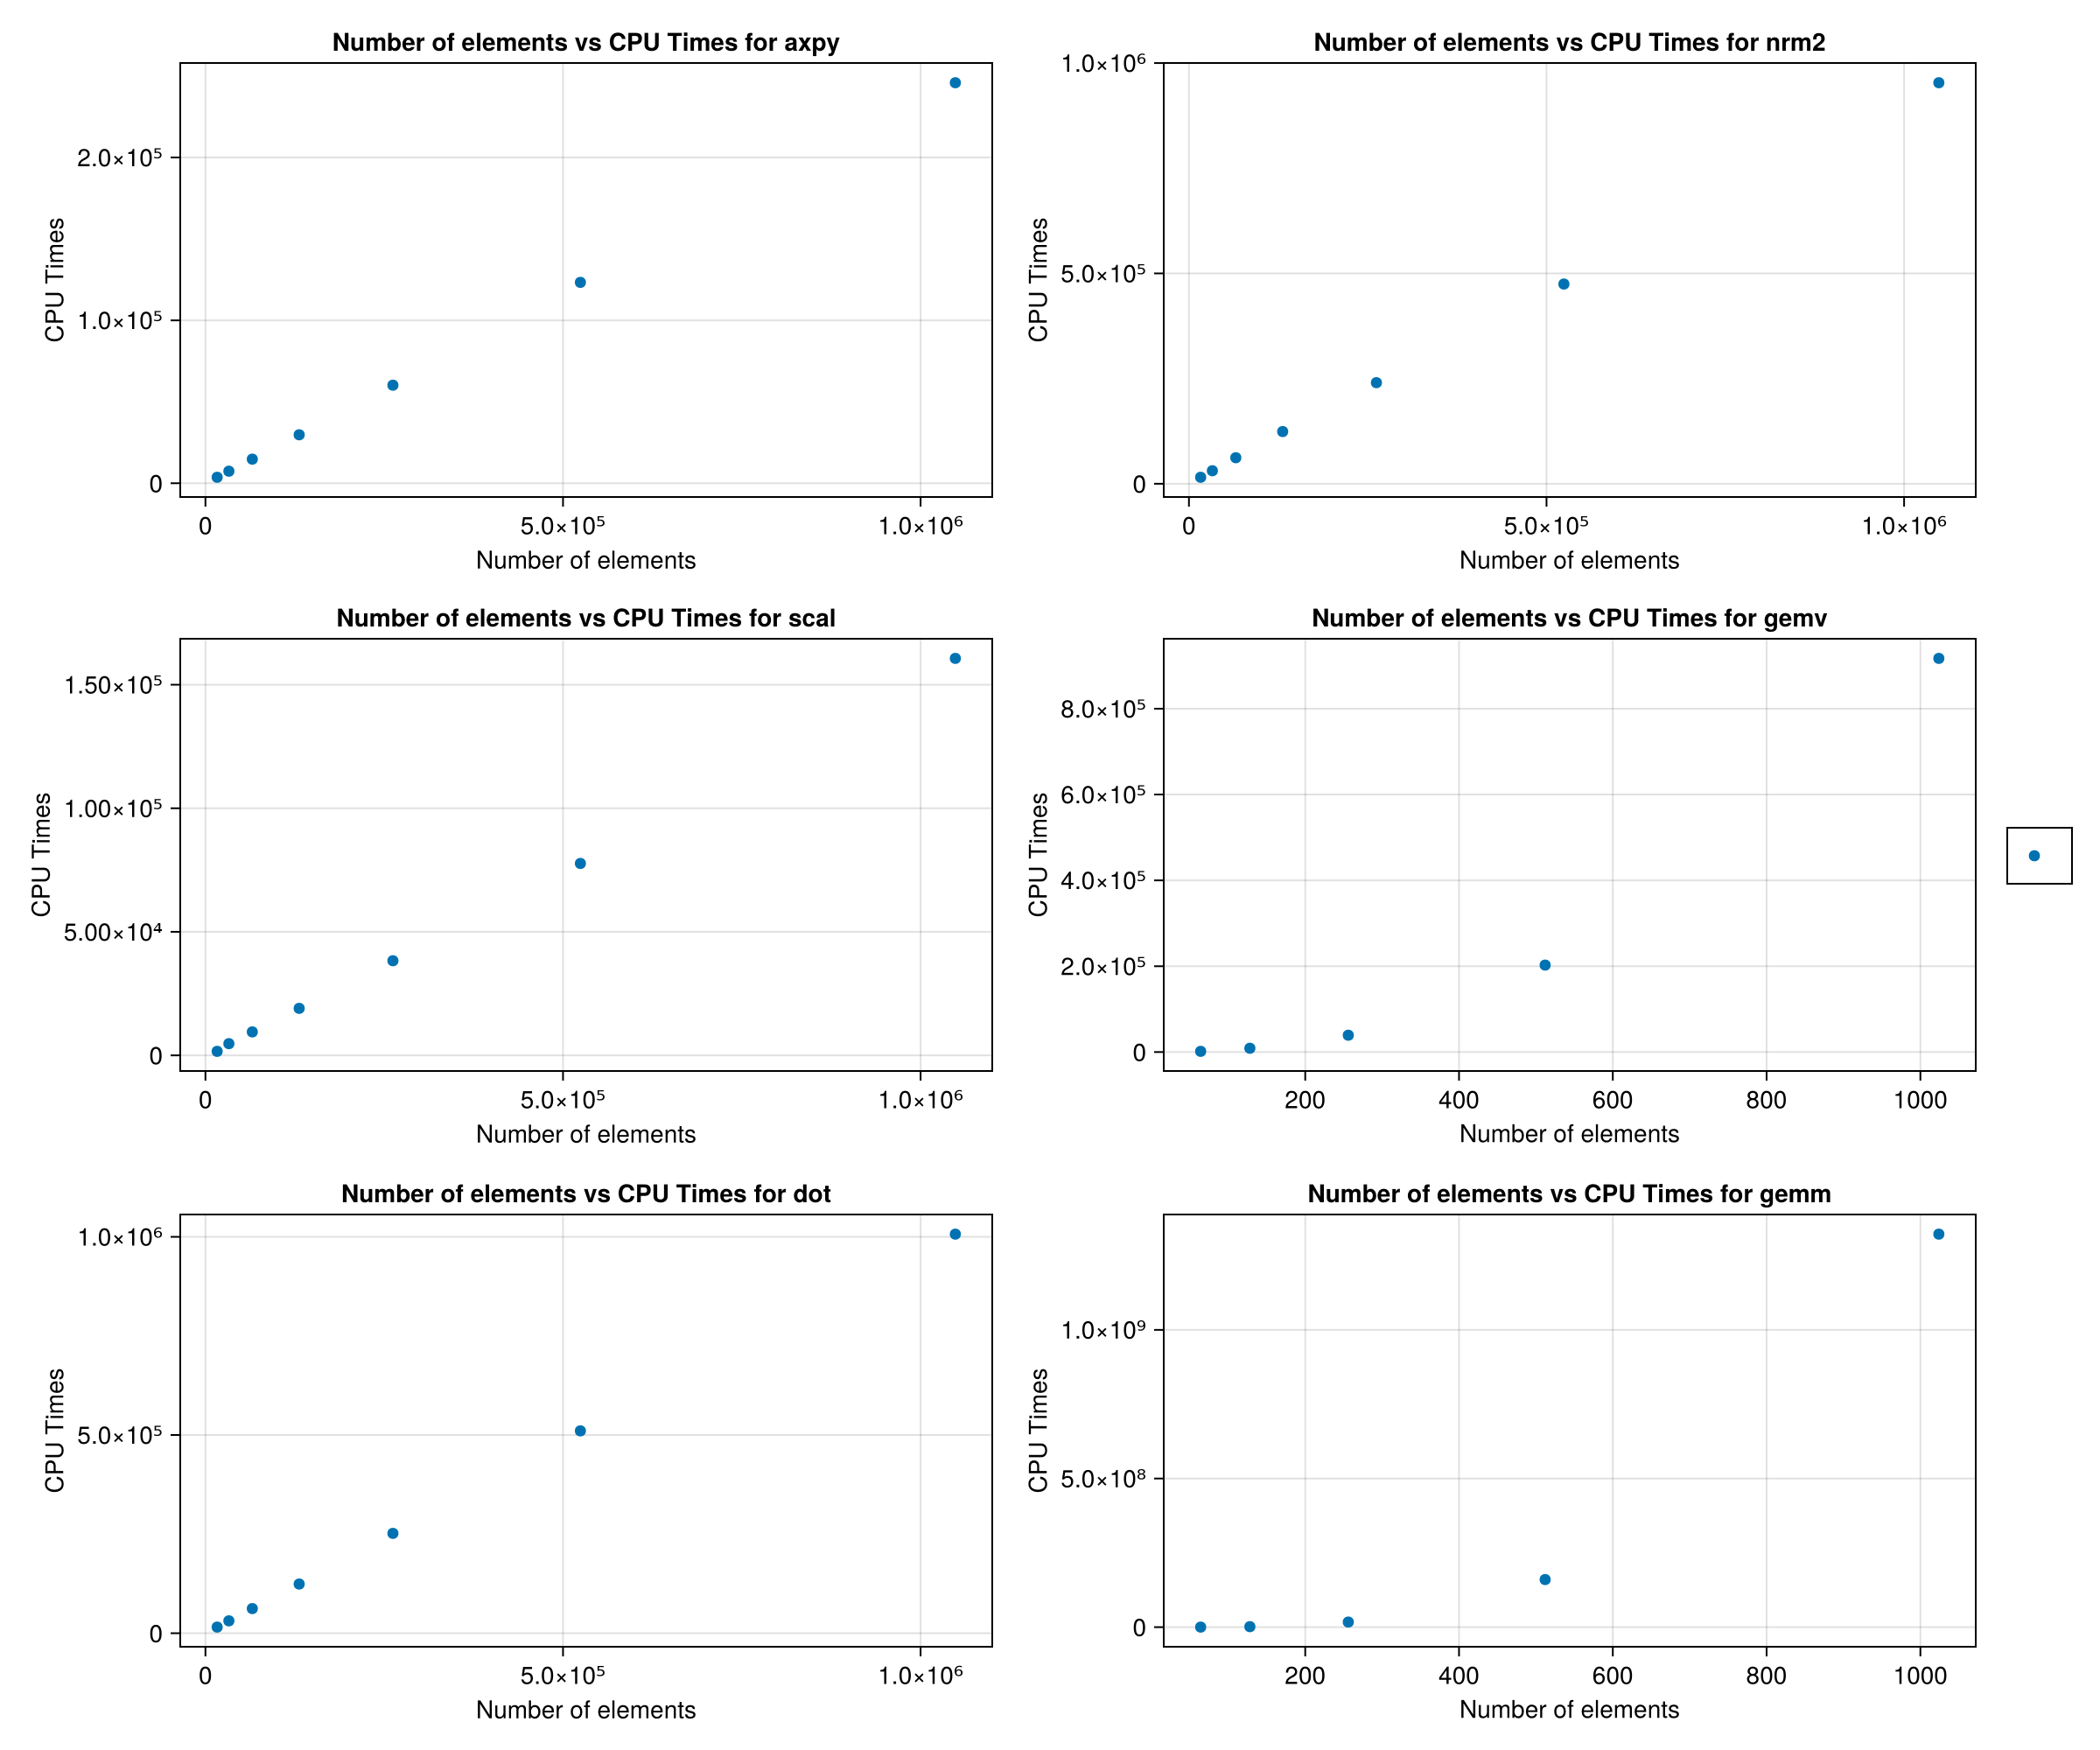

In [204]:
fig = PlotStatistics(baseline_names, baseline_num_elems, baseline_cpu_times, [range(1, length(baseline_names))], [""], "CPU Times")
save("./data/baseline_cpu_times_comparison.png", fig)

fig

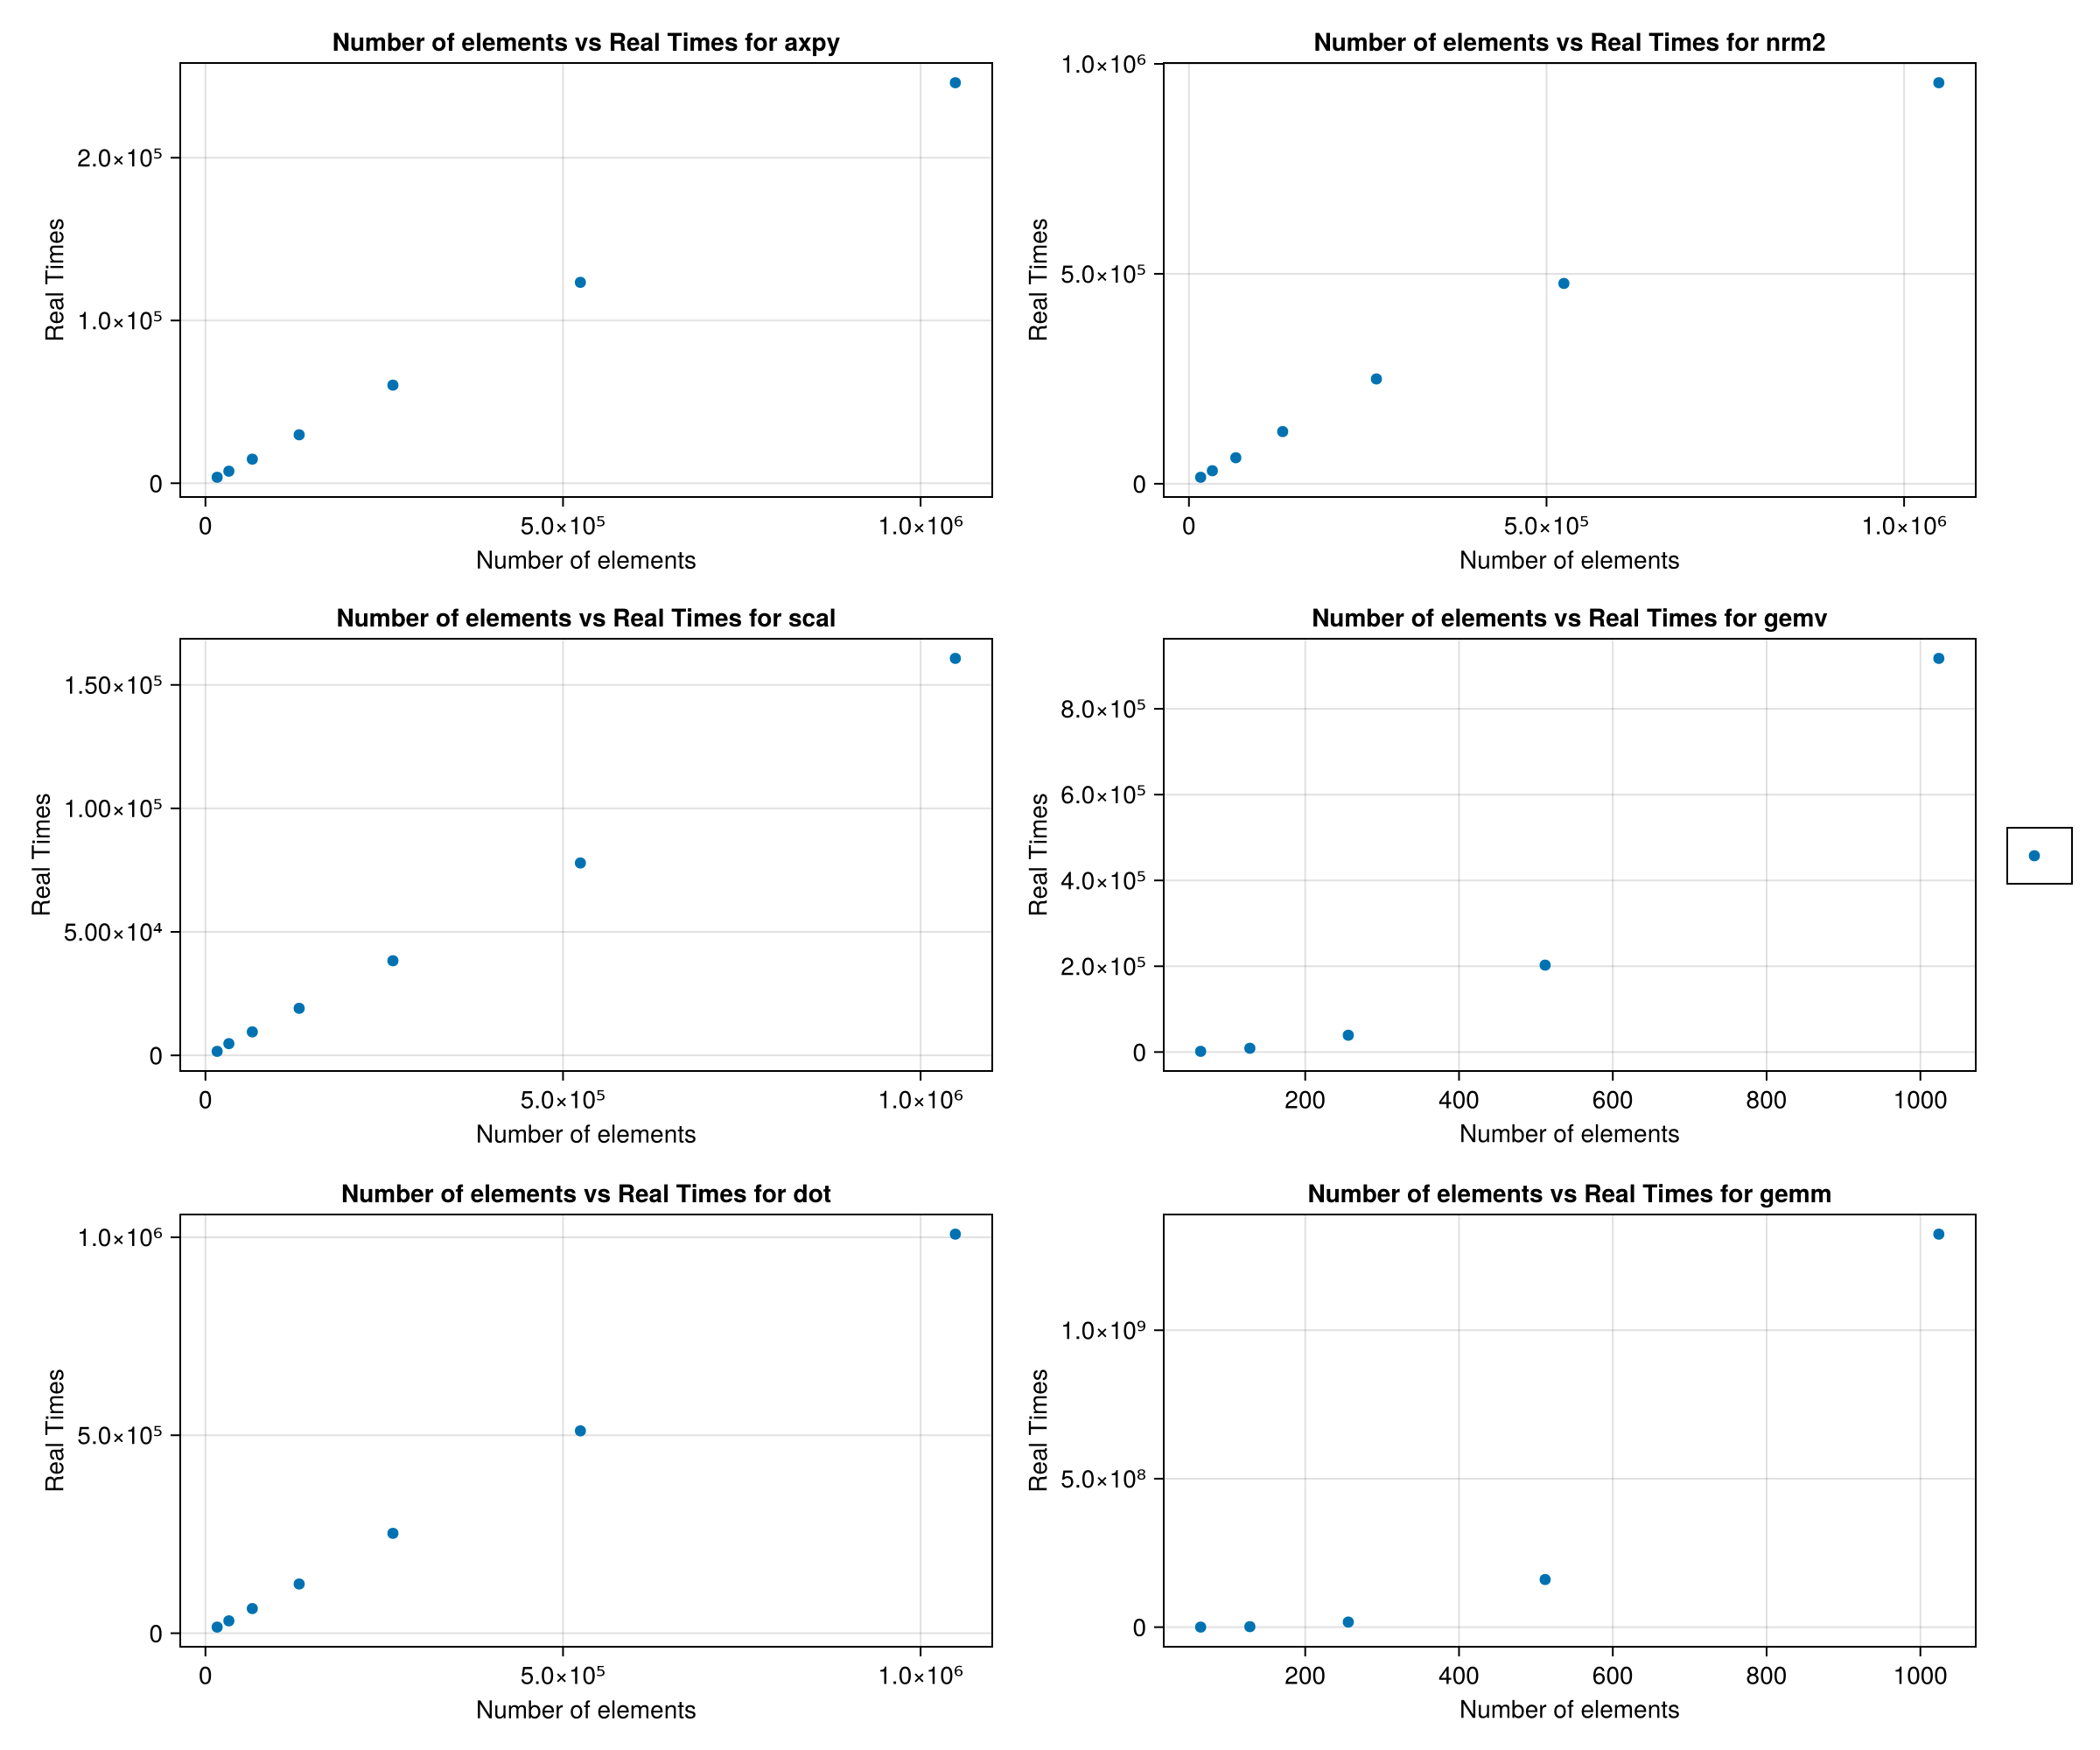

In [205]:
fig = PlotStatistics(baseline_names, baseline_num_elems, baseline_real_times, [range(1, length(baseline_names))], [""], "Real Times")
save("./data/baseline_run_times_comparison.png", fig)

fig

### Parallelization
Here, we use OpenMP to naïvely parallelize a given BLAS routine using `nthreads`

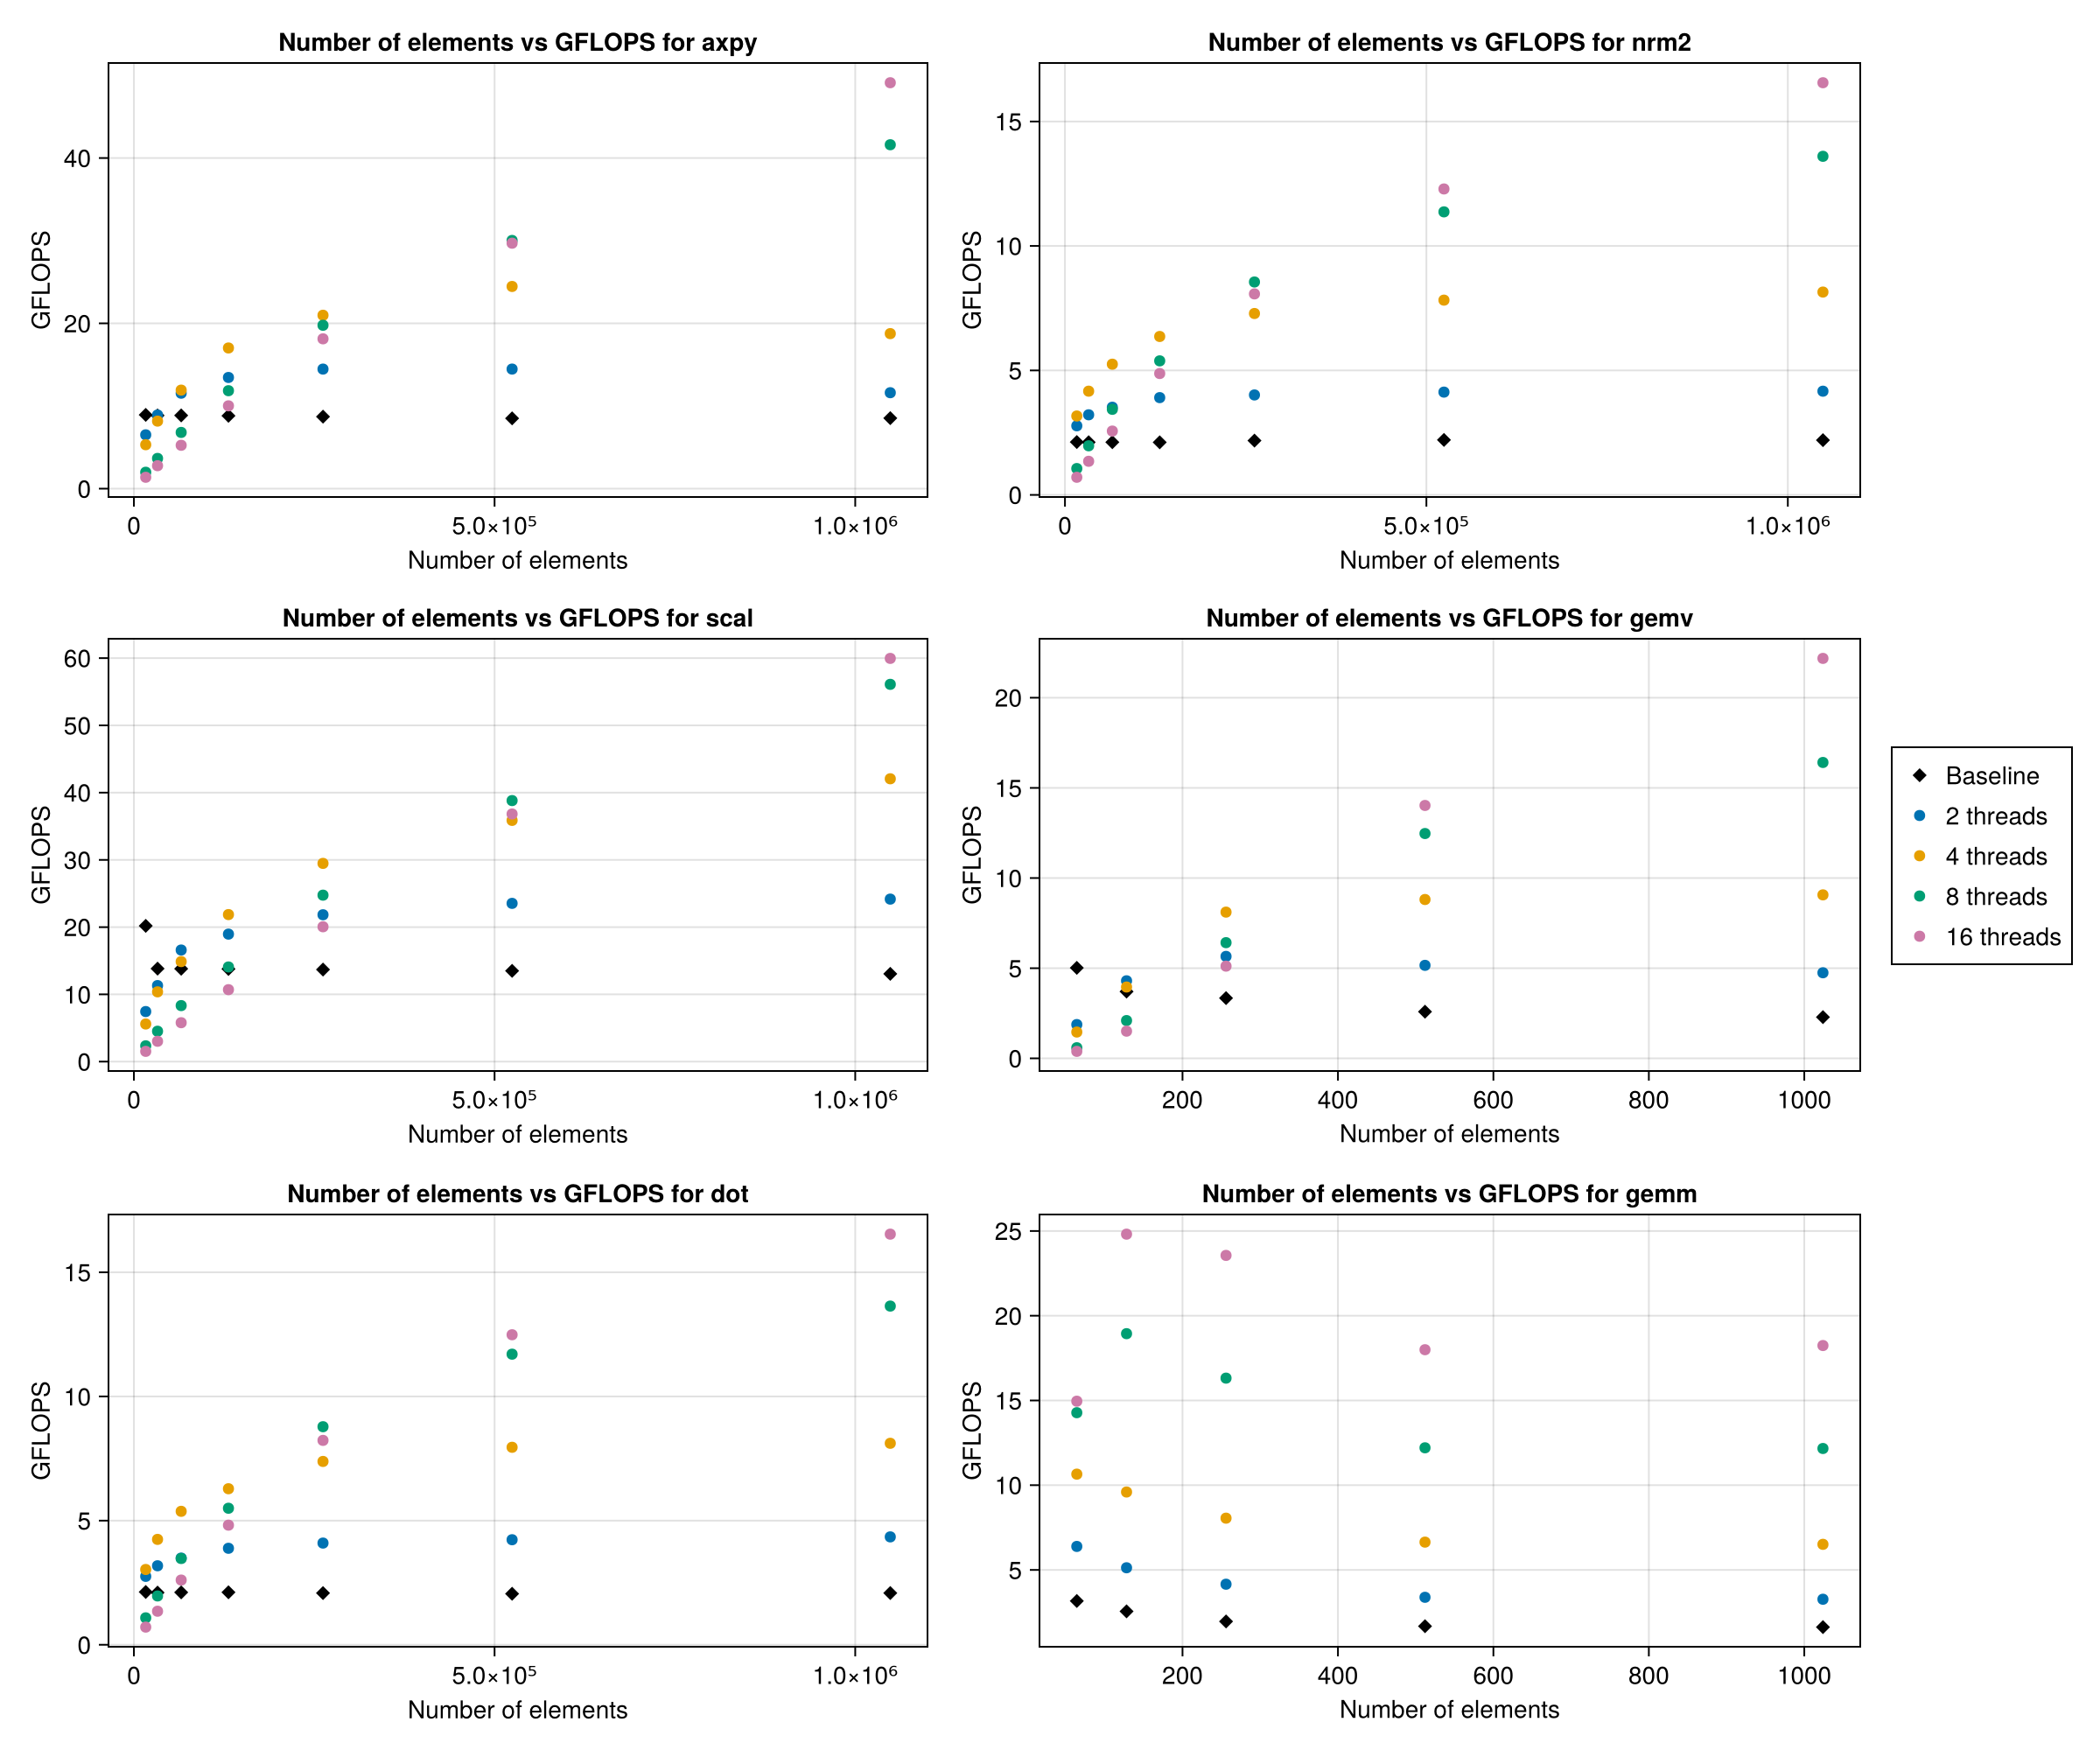

In [206]:
fig = PlotStatistics(
    parallel_names, parallel_num_elems, parallel_GFLOPS,
    threads_arr, ["2 threads", "4 threads", "8 threads", "16 threads"], "GFLOPS";
    baseline_names = baseline_names,
    baseline_num_elems = baseline_num_elems,
    baseline_statistics = baseline_GFLOPS,
    baseline_label = "Baseline"
)

save("./data/parallel_GFLOPS_comparison.png", fig)

fig

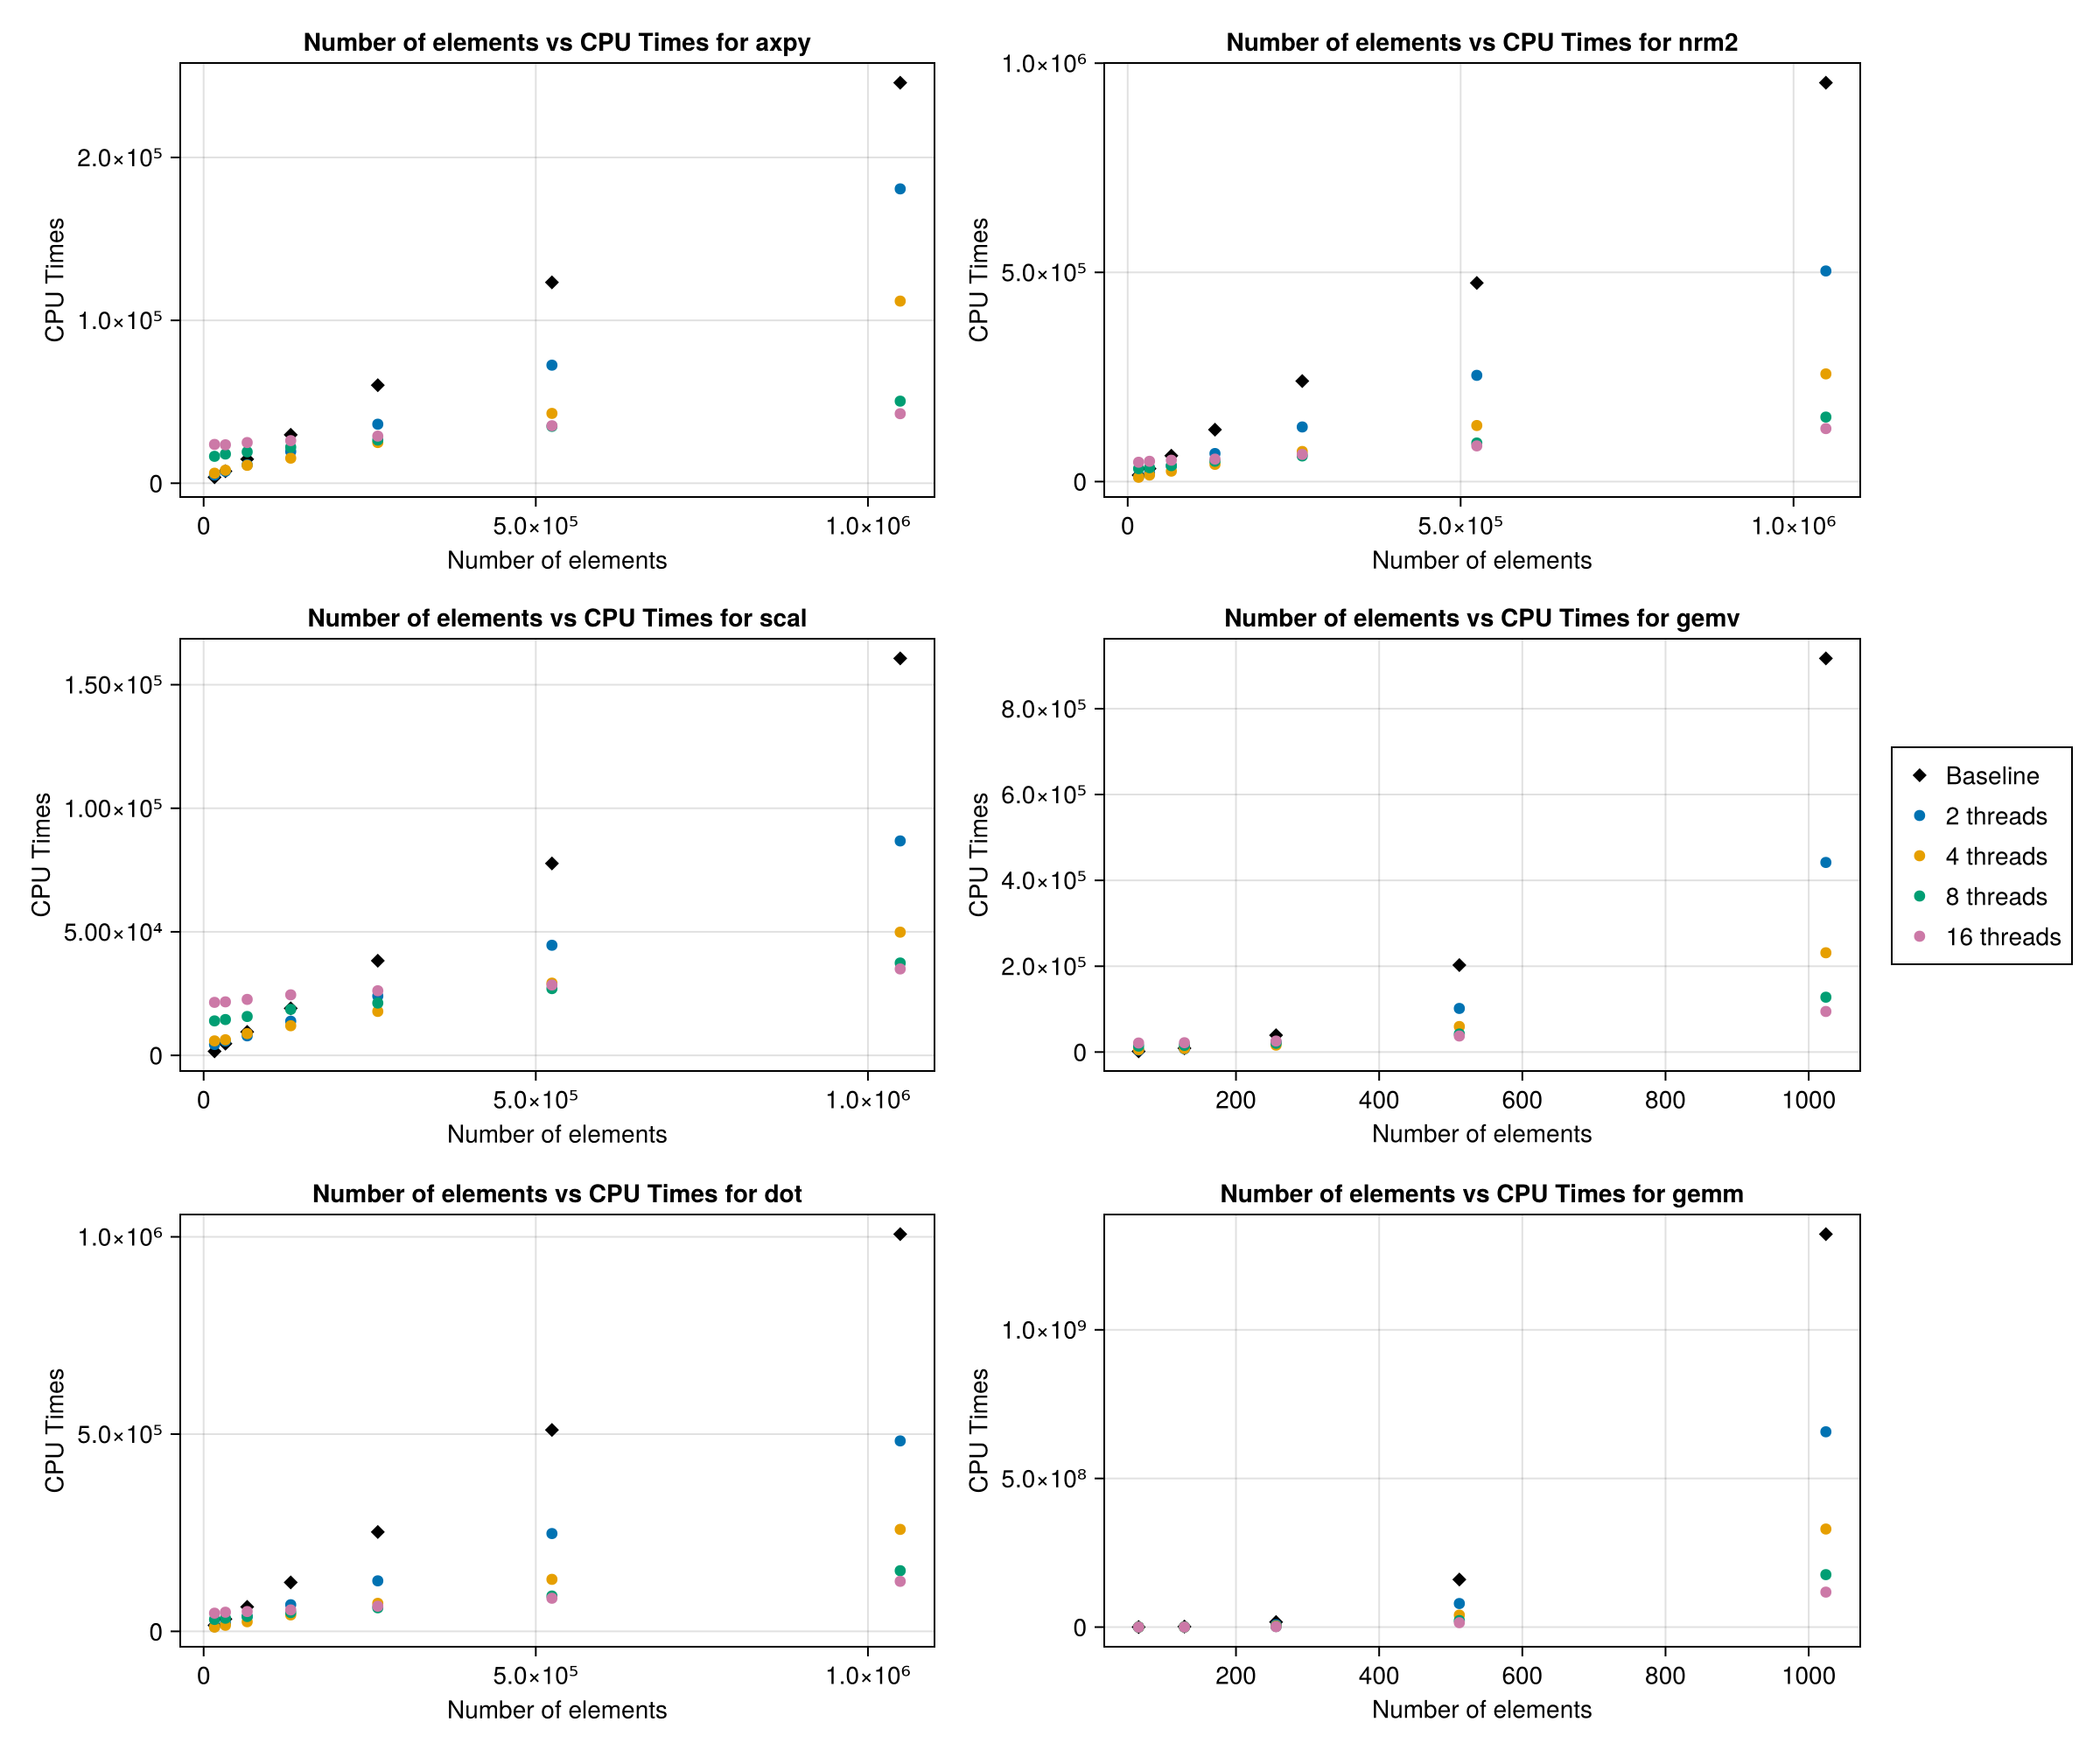

In [207]:
fig = PlotStatistics(
    parallel_names, parallel_num_elems, parallel_cpu_times,
    threads_arr, ["2 threads", "4 threads", "8 threads", "16 threads"], "CPU Times";
    baseline_names = baseline_names,
    baseline_num_elems = baseline_num_elems,
    baseline_statistics = baseline_cpu_times,
    baseline_label = "Baseline"
)

save("./data/parallel_cpu_times_comparison.png", fig)

fig

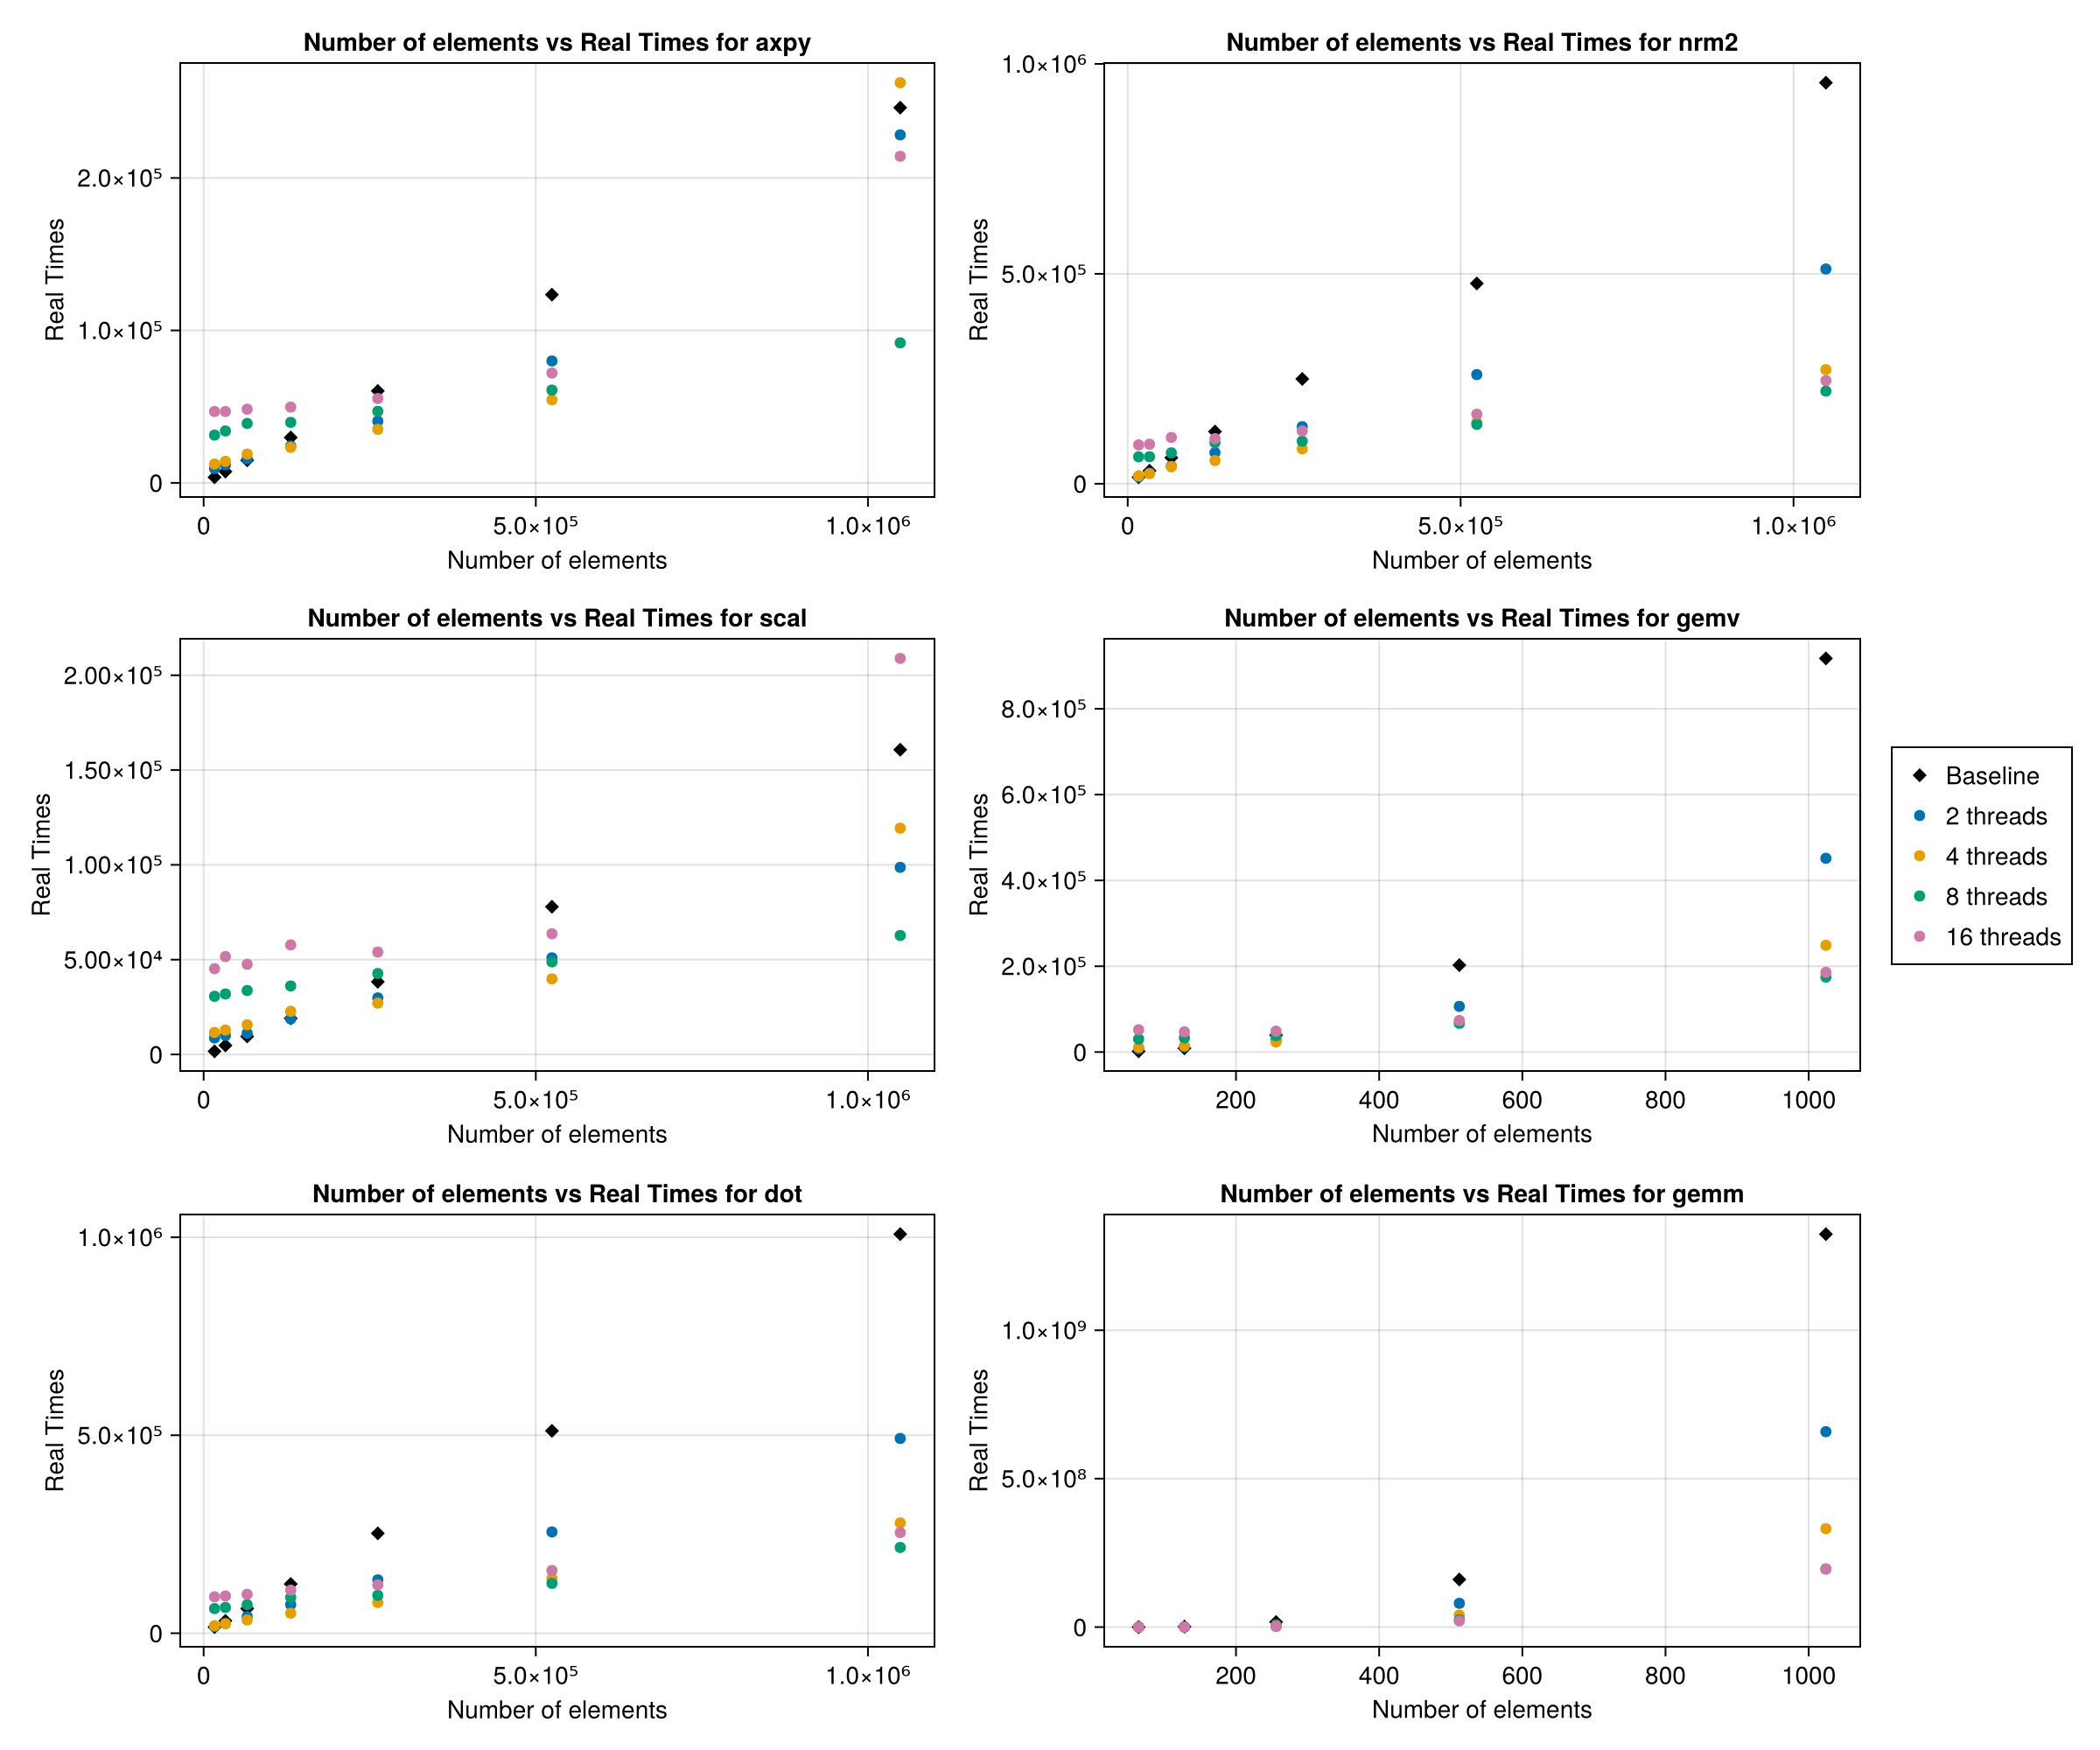

In [208]:
fig = PlotStatistics(
    parallel_names, parallel_num_elems, parallel_real_times,
    threads_arr, ["2 threads", "4 threads", "8 threads", "16 threads"], "Real Times";
    baseline_names = baseline_names,
    baseline_num_elems = baseline_num_elems,
    baseline_statistics = baseline_real_times,
    baseline_label = "Baseline"
)

save("./data/parallel_real_times_comparison.png", fig)

fig

### Cache Conscious Programming